# S10_model_diagnostics

Diagnostics and robustness checks for the binary endpoint models
Main analysis models in this project are Firth logistic models (see config).
This notebook provides:
- cohort integrity / event-count diagnostics
- collinearity (VIF)
- calibration and discrimination summaries
- Hosmer-Lemeshow test (descriptive only; interpret cautiously)
- auxiliary approximate influence diagnostics using standard Logit
- auxiliary age functional-form check (linear vs spline)

## Imports

In [ ]:

import json
from pathlib import Path
from typing import List, Tuple, Optional, Dict

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from scipy.stats import chi2
from sklearn.metrics import roc_auc_score, brier_score_loss
from sklearn.calibration import calibration_curve

import statsmodels.api as sm
from statsmodels.stats.outliers_influence import variance_inflation_factor

RANDOM_SEED = 20260222
rng = np.random.default_rng(RANDOM_SEED)

## Config

In [ ]:
CONFIG_SNAPSHOT = Path("/mnt/data/config_snapshot.json")
if not CONFIG_SNAPSHOT.exists():
    CONFIG_SNAPSHOT = Path("/content/reports/config_snapshot.json")
if not CONFIG_SNAPSHOT.exists():
    CONFIG_SNAPSHOT = Path("/content/config_snapshot.json")
if not CONFIG_SNAPSHOT.exists():
    raise FileNotFoundError("config_snapshot.json not found. Run S00 first or upload the snapshot.")

with open(CONFIG_SNAPSHOT, "r", encoding="utf-8") as f:
    CFG = json.load(f)

tables_dir = Path(CFG["paths"]["tables_dir"])
figures_dir = Path(CFG["paths"]["figures_dir"])
reports_dir = Path(CFG["paths"]["reports_dir"])
supplementary_dir = Path(CFG["paths"].get("supplementary_dir", tables_dir))

tables_dir.mkdir(parents=True, exist_ok=True)
figures_dir.mkdir(parents=True, exist_ok=True)
reports_dir.mkdir(parents=True, exist_ok=True)
supplementary_dir.mkdir(parents=True, exist_ok=True)

PRIMARY_MODEL_KIND = str(CFG["analysis"].get("primary_binary_model", "unknown")).lower()
SECONDARY_MODEL_KIND = str(CFG["analysis"].get("secondary_binary_model", "unknown")).lower()
RARE_EVENT_THRESHOLD = int(CFG["analysis"].get("rare_event_warning_threshold", 10))

print("Loaded config snapshot:", CONFIG_SNAPSHOT)
print("primary_binary_model:", PRIMARY_MODEL_KIND)
print("secondary_binary_model:", SECONDARY_MODEL_KIND)
print("rare_event_warning_threshold:", RARE_EVENT_THRESHOLD)
print("tables_dir:", tables_dir)
print("figures_dir:", figures_dir)

Loaded config snapshot: /content/config_snapshot.json
primary_binary_model: firth
secondary_binary_model: firth
rare_event_warning_threshold: 10
tables_dir: /content/outputs/tables
figures_dir: /content/outputs/figures


## Load data

In [ ]:
DATA_PATH = Path("/mnt/data/pcos_analysis.parquet")
if not DATA_PATH.exists():
    DATA_PATH = Path("/content/pcos_analysis.parquet")
if not DATA_PATH.exists():
    DATA_PATH = Path("/mnt/data/pcos_analysis.csv")
if not DATA_PATH.exists():
    DATA_PATH = Path("/content/pcos_analysis.csv")
if not DATA_PATH.exists():
    raise FileNotFoundError("Missing pcos_analysis.parquet/csv. Run S03 first.")

if str(DATA_PATH).endswith(".parquet"):
    df = pd.read_parquet(DATA_PATH)
else:
    df = pd.read_csv(DATA_PATH)

print("Using data:", DATA_PATH)
print("Shape:", df.shape)
print("Columns (sample):", list(df.columns[:30]))

Using data: /content/pcos_analysis.parquet
Shape: (1300, 77)
Columns (sample): ['id', 'age', 'anti_tpo', 'anti_tg', 'tsh', 'ft4', 'ft3', 'tg', 'hdl', 'tc', 'ldl', 'glu0', 'glu120', 'tt', 'ft', 'shbg', 'dheas', 'andro', 'amh', 'lh', 'fsh', 'ins0', 'ins120', 'insulin', 'lt4_use', 'out_age', 'out_tsh', 'out_anti_tpo', 'out_anti_tg', 'out_ft4']


## Helpers

In [ ]:
def build_logistic_cohort(
    df_in: pd.DataFrame,
    exposure: str,
    endpoint: str,
    covars: List[str],
    extra_filter: Optional[pd.Series] = None
) -> Tuple[pd.DataFrame, pd.DataFrame, pd.Series]:
    """
    Build an aligned complete-case cohort for a binary endpoint model.
    Returns:
    - dfm: modeling dataframe
    - X: design matrix
    - y: binary outcome
    """
    dfm = df_in.copy()

    if extra_filter is not None:
        dfm = dfm.loc[extra_filter].copy()

    required = [exposure, endpoint] + covars
    for c in required:
        if c not in dfm.columns:
            raise KeyError(f"Missing required column: {c}")

    for c in required:
        dfm[c] = pd.to_numeric(dfm[c], errors="coerce")

    keep_mask = dfm[required].notna().all(axis=1)
    dfm = dfm.loc[keep_mask].copy()

    X = pd.DataFrame(
        {"TAI": dfm[exposure].astype(float), **{c: dfm[c].astype(float) for c in covars}},
        index=dfm.index
    )
    y = dfm[endpoint].astype(int)

    dfm = dfm.reset_index(drop=True)
    X = X.reset_index(drop=True)
    y = y.reset_index(drop=True)

    return dfm, X, y


def summarize_events_by_exposure(dfm: pd.DataFrame, exposure: str, endpoint: str) -> Dict[str, float]:
    exp = pd.to_numeric(dfm[exposure], errors="coerce")
    out = pd.to_numeric(dfm[endpoint], errors="coerce")

    tai_pos = exp == 1
    tai_neg = exp == 0

    n_pos = int(tai_pos.sum())
    n_neg = int(tai_neg.sum())
    ev_pos = int(out.loc[tai_pos].sum()) if n_pos > 0 else 0
    ev_neg = int(out.loc[tai_neg].sum()) if n_neg > 0 else 0

    return {
        "n_tai_pos": n_pos,
        "n_tai_neg": n_neg,
        "events_tai_pos": ev_pos,
        "events_tai_neg": ev_neg,
        "risk_tai_pos": float(ev_pos / n_pos) if n_pos > 0 else np.nan,
        "risk_tai_neg": float(ev_neg / n_neg) if n_neg > 0 else np.nan,
        "rare_event_warning_tai_pos": bool(ev_pos < RARE_EVENT_THRESHOLD),
        "rare_event_warning_total": bool((ev_pos + ev_neg) < RARE_EVENT_THRESHOLD),
    }

## Exposure, covars, endpoints

In [ ]:
EXPOSURE = "tai_A"

COVARS = ["age"]

ENDPOINTS = {
    "primary": "ep_primary",
    "secondary_non_hdl": "ep_non_hdl",
    "secondary_ogtt120": "ep_ogtt120",
}

if EXPOSURE not in df.columns:
    raise KeyError("Expected exposure column 'tai_A' in df. Run S03 first.")

for label, ep in ENDPOINTS.items():
    if ep not in df.columns:
        print(f"WARNING: endpoint missing: {ep}")

print("Exposure:", EXPOSURE)
print("Covariates:", COVARS)
print("Endpoints:", ENDPOINTS)

Exposure: tai_A
Covariates: ['age']
Endpoints: {'primary': 'ep_primary', 'secondary_non_hdl': 'ep_non_hdl', 'secondary_ogtt120': 'ep_ogtt120'}


## Auxiliary model for prediction diagnostics

In [ ]:
def fit_aux_logit(X: pd.DataFrame, y: pd.Series):
    """
    Auxiliary standard logistic regression used only for diagnostic quantities
    that require fitted probabilities / influence objects from common libraries.
    This is NOT the reported primary estimator when the project uses Firth models.
    """
    Xs = sm.add_constant(X, has_constant="add")
    model = sm.Logit(y, Xs).fit(disp=False)
    return model


def predict_proba_from_sm(model, X: pd.DataFrame) -> np.ndarray:
    Xs = sm.add_constant(X, has_constant="add")
    p = model.predict(Xs)
    return np.asarray(p, dtype=float)

## AUC, calibration, Brier

In [ ]:
def bootstrap_auc_ci(y: np.ndarray, p: np.ndarray, n_boot: int = 2000, seed: int = 123) -> Dict[str, float]:
    rng = np.random.default_rng(seed)
    n = len(y)
    aucs = []

    for _ in range(n_boot):
        idx = rng.integers(0, n, size=n)
        yb = y[idx]
        pb = p[idx]
        if len(np.unique(yb)) < 2:
            continue
        aucs.append(roc_auc_score(yb, pb))

    auc_obs = float(roc_auc_score(y, p))
    if len(aucs) < 50:
        return {
            "auc": auc_obs,
            "auc_ci_low": np.nan,
            "auc_ci_high": np.nan,
            "n_boot_ok": int(len(aucs))
        }

    aucs = np.asarray(aucs)
    return {
        "auc": auc_obs,
        "auc_ci_low": float(np.quantile(aucs, 0.025)),
        "auc_ci_high": float(np.quantile(aucs, 0.975)),
        "n_boot_ok": int(len(aucs))
    }


def calibration_intercept_slope(y: np.ndarray, p: np.ndarray) -> Dict[str, float]:
    """
    Logistic calibration model:
        logit(y) ~ a + b * logit(p)
    Perfect calibration: intercept=0, slope=1
    """
    eps = 1e-6
    p = np.clip(p, eps, 1 - eps)
    logit_p = np.log(p / (1 - p))
    Xc = sm.add_constant(logit_p)

    try:
        m = sm.Logit(y, Xc).fit(disp=False)
        return {
            "cal_intercept": float(m.params[0]),
            "cal_slope": float(m.params[1])
        }
    except Exception:
        return {
            "cal_intercept": np.nan,
            "cal_slope": np.nan
        }

## VIF i HL

In [ ]:
def compute_vif(X: pd.DataFrame) -> pd.DataFrame:
    """
    Compute VIF on feature columns only (without explicit intercept column).
    With only age + TAI, VIF is expected to be low unless coding issues exist.
    """
    Xv = X.copy().replace([np.inf, -np.inf], np.nan).dropna()

    if Xv.shape[0] < 10 or Xv.shape[1] < 2:
        return pd.DataFrame({"term": list(X.columns), "VIF": [np.nan] * len(X.columns)})

    vals = Xv.to_numpy()
    out = []
    for j, name in enumerate(Xv.columns):
        try:
            out.append({"term": name, "VIF": float(variance_inflation_factor(vals, j))})
        except Exception:
            out.append({"term": name, "VIF": np.nan})
    return pd.DataFrame(out)


def hosmer_lemeshow_test(y: np.ndarray, p: np.ndarray, g: int = 10) -> Dict[str, float]:
    """
    Classic Hosmer-Lemeshow test using quantile groups of predicted risk.
    Descriptive only; interpret cautiously, especially with rare events.
    """
    eps = 1e-12
    p = np.clip(p, eps, 1 - eps)

    df_hl = pd.DataFrame({"y": y, "p": p})
    df_hl["bin"] = pd.qcut(df_hl["p"].rank(method="first"), q=g, labels=False, duplicates="drop")

    grp = df_hl.groupby("bin", observed=False)
    obs = grp["y"].sum()
    exp = grp["p"].sum()
    n = grp["y"].count()

    exp = exp.clip(lower=eps)
    nonexp = (n - exp).clip(lower=eps)

    hl_components = (((obs - exp) ** 2) / exp) + ((((n - obs) - (n - exp)) ** 2) / nonexp)
    hl_stat = float(hl_components.sum())
    dof = max(int(len(obs) - 2), 1)
    pval = float(chi2.sf(hl_stat, dof))

    return {
        "hl_stat": hl_stat,
        "hl_df": dof,
        "hl_p": pval,
        "hl_groups_used": int(len(obs))
    }

## Influence diagnostics

In [ ]:
def influence_table_from_aux_logit(m_sm, X: pd.DataFrame) -> pd.DataFrame:
    """
    Approximate influence diagnostics from standard Logit.
    These are auxiliary diagnostics and not exact Firth-based influence measures.
    """
    infl = m_sm.get_influence()

    hat = infl.hat_matrix_diag
    cooks = infl.cooks_distance[0]
    dfb = infl.dfbetas

    dfb_cols = ["dfbeta_const"] + [f"dfbeta_{c}" for c in X.columns]

    out = pd.DataFrame({
        "leverage": hat,
        "cooks_d": cooks,
    })
    out = pd.concat([out, pd.DataFrame(dfb, columns=dfb_cols)], axis=1)
    return out

## Main diagnostic loop

In [ ]:
N_BOOT = 2000

diag_rows = []
vif_rows = []
hl_rows = []
cohort_rows = []

for label, endpoint in ENDPOINTS.items():
    if endpoint not in df.columns:
        continue

    try:
        dfm, X, y = build_logistic_cohort(
            df,
            exposure=EXPOSURE,
            endpoint=endpoint,
            covars=COVARS
        )
    except Exception as e:
        diag_rows.append({
            "model_set": label,
            "endpoint": endpoint,
            "status": f"failed_build: {repr(e)}"
        })
        continue

    if y.nunique() < 2:
        diag_rows.append({
            "model_set": label,
            "endpoint": endpoint,
            "status": "skipped_no_outcome_variation",
            "n": int(len(y)),
            "events_total": int(y.sum())
        })
        continue

    # cohort/event summary
    event_info = summarize_events_by_exposure(dfm, exposure=EXPOSURE, endpoint=endpoint)
    cohort_rows.append({
        "model_set": label,
        "endpoint": endpoint,
        "n_complete_case": int(len(dfm)),
        "events_total": int(y.sum()),
        "prevalence": float(y.mean()),
        **event_info
    })

    # auxiliary standard logit for diagnostic quantities requiring p-hat
    try:
        m_aux = fit_aux_logit(X, y)
        p = predict_proba_from_sm(m_aux, X)
        status = "ok_aux_logit"
    except Exception as e:
        diag_rows.append({
            "model_set": label,
            "endpoint": endpoint,
            "status": f"failed_aux_logit: {repr(e)}",
            "n": int(len(y)),
            "events_total": int(y.sum()),
            **event_info
        })
        continue

    auc_info = bootstrap_auc_ci(y.to_numpy(), p, n_boot=N_BOOT, seed=RANDOM_SEED)
    cal_info = calibration_intercept_slope(y.to_numpy(), p)
    brier = float(brier_score_loss(y.to_numpy(), p))

    diag_rows.append({
        "model_set": label,
        "endpoint": endpoint,
        "status": status,
        "reported_estimator": PRIMARY_MODEL_KIND if label == "primary" else SECONDARY_MODEL_KIND,
        "diagnostic_probability_model": "standard_logit_auxiliary",
        "n": int(len(y)),
        "events_total": int(y.sum()),
        "prevalence": float(y.mean()),
        "rare_event_warning_tai_pos": event_info["rare_event_warning_tai_pos"],
        "brier": brier,
        **auc_info,
        **cal_info
    })

    vif_df = compute_vif(X)
    vif_df["model_set"] = label
    vif_df["endpoint"] = endpoint
    vif_rows.append(vif_df)

    hl = hosmer_lemeshow_test(y.to_numpy(), p, g=10)
    hl_rows.append({
        "model_set": label,
        "endpoint": endpoint,
        "note": "Descriptive only; interpret cautiously, especially with sparse events.",
        **hl
    })

diagn = pd.DataFrame(diag_rows)
cohort_df = pd.DataFrame(cohort_rows)
vif_all = pd.concat(vif_rows, ignore_index=True) if vif_rows else pd.DataFrame()
hl_df = pd.DataFrame(hl_rows)

out_diag = tables_dir / "TableS10_model_diagnostics.csv"
out_cohort = tables_dir / "TableS10_cohort_integrity_and_events.csv"
out_vif = tables_dir / "TableS10_VIF.csv"
out_hl = tables_dir / "TableS10_HL.csv"

diagn.to_csv(out_diag, index=False)
cohort_df.to_csv(out_cohort, index=False)
vif_all.to_csv(out_vif, index=False)
hl_df.to_csv(out_hl, index=False)

print("Saved:", out_diag)
print("Saved:", out_cohort)
print("Saved:", out_vif)
print("Saved:", out_hl)

diagn

Saved: /content/outputs/tables/TableS10_model_diagnostics.csv
Saved: /content/outputs/tables/TableS10_cohort_integrity_and_events.csv
Saved: /content/outputs/tables/TableS10_VIF.csv
Saved: /content/outputs/tables/TableS10_HL.csv


,model_set,endpoint,status,reported_estimator,diagnostic_probability_model,n,events_total,prevalence,rare_event_warning_tai_pos,brier,auc,auc_ci_low,auc_ci_high,n_boot_ok,cal_intercept,cal_slope
0,primary,ep_primary,ok_aux_logit,firth,standard_logit_auxiliary,1053,70,0.066477,True,0.061990,0.529233,0.453005,0.608191,2000,-1.441424e-13,1.0
1,secondary_non_hdl,ep_non_hdl,ok_aux_logit,firth,standard_logit_auxiliary,1053,224,0.212726,False,0.166722,0.552107,0.505853,0.595187,2000,-3.091666e-14,1.0
2,secondary_ogtt120,ep_ogtt120,ok_aux_logit,firth,standard_logit_auxiliary,1035,156,0.150725,False,0.127949,0.507023,0.459832,0.558934,2000,8.556648e-15,1.0


## Calibration plots

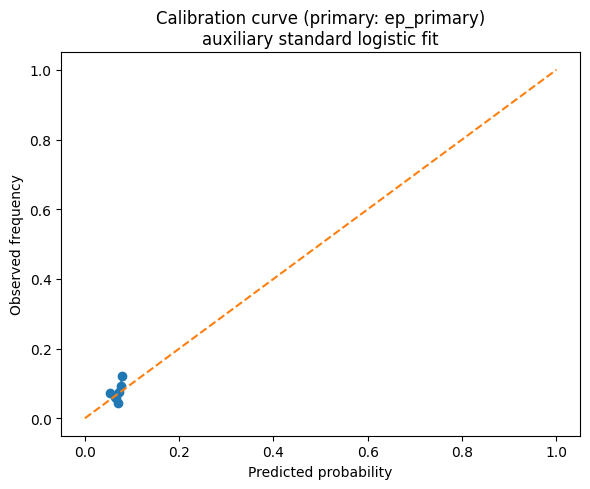

Saved: /content/outputs/figures/F_S10_calibration_ep_primary.png


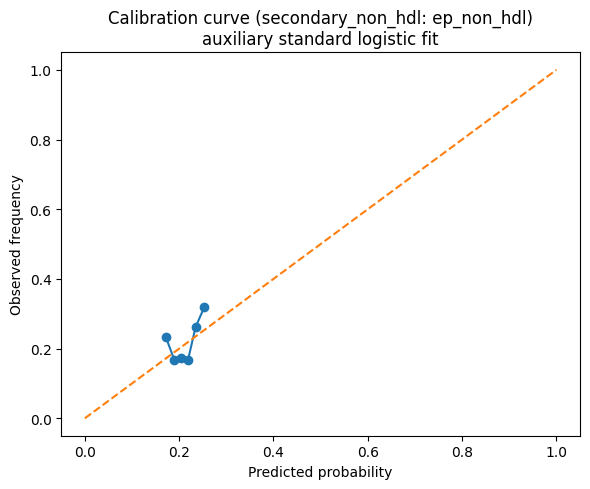

Saved: /content/outputs/figures/F_S10_calibration_ep_non_hdl.png


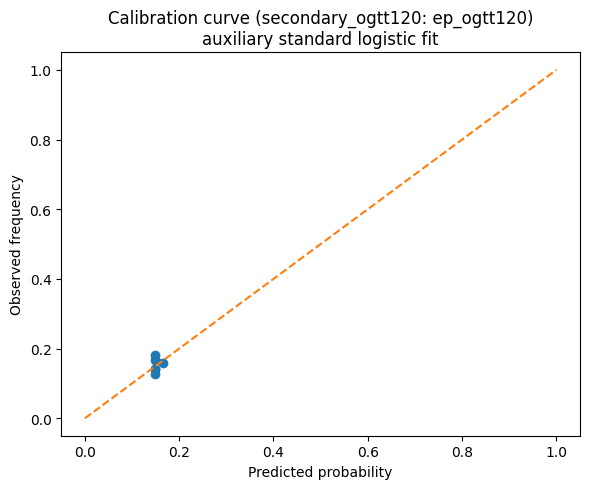

Saved: /content/outputs/figures/F_S10_calibration_ep_ogtt120.png


In [ ]:
def plot_calibration(y: np.ndarray, p: np.ndarray, title: str, outpath: Path, n_bins: int = 8) -> None:
    frac_pos, mean_pred = calibration_curve(y, p, n_bins=n_bins, strategy="quantile")

    fig, ax = plt.subplots(figsize=(6, 5))
    ax.plot(mean_pred, frac_pos, marker="o")
    ax.plot([0, 1], [0, 1], linestyle="--")
    ax.set_xlabel("Predicted probability")
    ax.set_ylabel("Observed frequency")
    ax.set_title(title)
    fig.tight_layout()
    fig.savefig(outpath, dpi=200, bbox_inches="tight")
    plt.show()


for label, endpoint in ENDPOINTS.items():
    if endpoint not in df.columns:
        continue

    try:
        dfm, X, y = build_logistic_cohort(df, exposure=EXPOSURE, endpoint=endpoint, covars=COVARS)
        if y.nunique() < 2:
            continue

        m_aux = fit_aux_logit(X, y)
        p = predict_proba_from_sm(m_aux, X)

        out_fig = figures_dir / f"F_S10_calibration_{endpoint}.png"
        plot_calibration(
            y.to_numpy(),
            p,
            title=f"Calibration curve ({label}: {endpoint})\nauxiliary standard logistic fit",
            outpath=out_fig,
            n_bins=8
        )
        print("Saved:", out_fig)
    except Exception as e:
        print(f"Skipping calibration plot for {endpoint}: {e}")

## Influence diagnostics dla primary

Saved: /content/outputs/tables/TableS10_influence_primary.csv


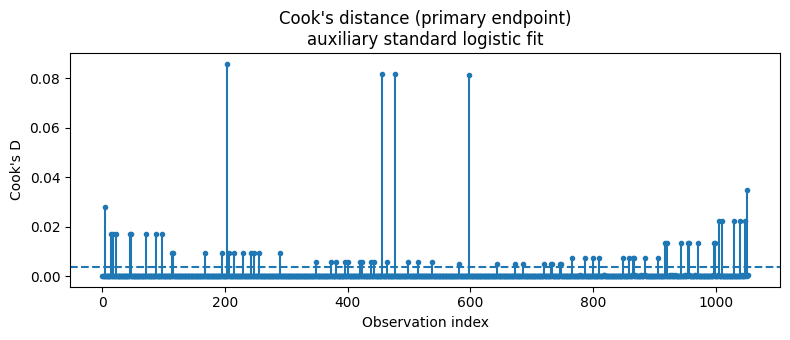

Saved: /content/outputs/figures/F_S10_cooks_primary.png


In [ ]:
PRIMARY_ENDPOINT = "ep_primary"

if PRIMARY_ENDPOINT in df.columns:
    try:
        dfm, X, y = build_logistic_cohort(df, exposure=EXPOSURE, endpoint=PRIMARY_ENDPOINT, covars=COVARS)

        if y.nunique() >= 2:
            m_aux = fit_aux_logit(X, y)
            infl = influence_table_from_aux_logit(m_aux, X)

            n = len(y)
            p_dim = X.shape[1] + 1
            leverage_thr = 2 * p_dim / n
            cooks_thr = 4 / n

            infl_out = infl.copy()
            infl_out["flag_high_leverage"] = infl_out["leverage"] > leverage_thr
            infl_out["flag_high_cooks"] = infl_out["cooks_d"] > cooks_thr
            infl_out["note"] = "Approximate influence diagnostics from auxiliary standard logit, not Firth-native."

            out_inf = tables_dir / "TableS10_influence_primary.csv"
            infl_out.to_csv(out_inf, index=False)
            print("Saved:", out_inf)

            fig, ax = plt.subplots(figsize=(8, 3.5))
            ax.stem(infl_out["cooks_d"].to_numpy(), linefmt="-", markerfmt=".", basefmt=" ")
            ax.axhline(cooks_thr, linestyle="--")
            ax.set_title("Cook's distance (primary endpoint)\nauxiliary standard logistic fit")
            ax.set_xlabel("Observation index")
            ax.set_ylabel("Cook's D")
            fig.tight_layout()

            out_fig = figures_dir / "F_S10_cooks_primary.png"
            fig.savefig(out_fig, dpi=200, bbox_inches="tight")
            plt.show()
            print("Saved:", out_fig)
    except Exception as e:
        print("Skipping influence diagnostics for primary:", e)

## Spline for age

In [ ]:
try:
    from patsy import dmatrix
    HAVE_PATSY = True
except Exception:
    HAVE_PATSY = False

if HAVE_PATSY and PRIMARY_ENDPOINT in df.columns:
    try:
        dfm, X_lin, y = build_logistic_cohort(df, exposure=EXPOSURE, endpoint=PRIMARY_ENDPOINT, covars=["age"])

        if y.nunique() >= 2:
            age = dfm["age"].astype(float).to_numpy()
            spline = dmatrix("0 + bs(x, df=4)", {"x": age}, return_type="dataframe")

            X_spl = pd.DataFrame({"TAI": X_lin["TAI"].to_numpy()}, index=dfm.index)
            X_spl = pd.concat([X_spl.reset_index(drop=True), spline.reset_index(drop=True)], axis=1)

            m_lin = sm.Logit(y, sm.add_constant(X_lin, has_constant="add")).fit(disp=False)
            m_spl = sm.Logit(y, sm.add_constant(X_spl, has_constant="add")).fit(disp=False)

            lr_stat = 2 * (m_spl.llf - m_lin.llf)
            df_diff = int(m_spl.df_model - m_lin.df_model)
            p_lr = float(chi2.sf(lr_stat, df_diff))

            out = pd.DataFrame([{
                "endpoint": PRIMARY_ENDPOINT,
                "comparison": "auxiliary standard logistic: spline(age) vs linear(age)",
                "lr_stat": float(lr_stat),
                "df_diff": df_diff,
                "p_value": p_lr,
                "AIC_linear": float(m_lin.aic),
                "AIC_spline": float(m_spl.aic),
                "note": "Auxiliary functional-form check; main reported models remain age-adjusted binary models per pipeline."
            }])

            out_path = tables_dir / "TableS10_age_spline_LR_primary.csv"
            out.to_csv(out_path, index=False)
            print("Saved:", out_path)
            out
    except Exception as e:
        print("Skipping spline check:", e)
else:
    print("Skipping spline check (patsy not available).")

Saved: /content/outputs/tables/TableS10_age_spline_LR_primary.csv


## Notes

In [ ]:
note_lines = []
note_lines.append("S10 model diagnostics and robustness checks")
note_lines.append("")
note_lines.append("This project uses Firth logistic regression as the reported estimator for binary endpoints.")
note_lines.append("Some diagnostic quantities available in common Python libraries (e.g., fitted influence measures,")
note_lines.append("certain calibration diagnostics, and spline-vs-linear auxiliary comparisons) were therefore")
note_lines.append("computed using an auxiliary standard logistic approximation on the same complete-case cohorts.")
note_lines.append("")
note_lines.append("Interpretation guidance:")
note_lines.append("1. Cohort integrity, event counts, and VIF are directly relevant to the reported analysis cohorts.")
note_lines.append("2. AUC, Brier score, calibration summaries, and Hosmer-Lemeshow are descriptive diagnostics.")
note_lines.append("3. Hosmer-Lemeshow should be interpreted cautiously, especially under sparse events.")
note_lines.append("4. Influence diagnostics and age spline checks are auxiliary approximations and not Firth-native diagnostics.")
note_lines.append("5. Sparse events in the TAI-positive group remain an important limitation for precision and model stability.")

out_note = reports_dir / "S10_diagnostics_note.txt"
out_note.write_text("\n".join(note_lines), encoding="utf-8")
print("Saved:", out_note)
print("\n".join(note_lines))

Saved: /content/reports/S10_diagnostics_note.txt
S10 model diagnostics and robustness checks

This project uses Firth logistic regression as the reported estimator for binary endpoints.
Some diagnostic quantities available in common Python libraries (e.g., fitted influence measures,
certain calibration diagnostics, and spline-vs-linear auxiliary comparisons) were therefore
computed using an auxiliary standard logistic approximation on the same complete-case cohorts.

Interpretation guidance:
1. Cohort integrity, event counts, and VIF are directly relevant to the reported analysis cohorts.
2. AUC, Brier score, calibration summaries, and Hosmer-Lemeshow are descriptive diagnostics.
3. Hosmer-Lemeshow should be interpreted cautiously, especially under sparse events.
4. Influence diagnostics and age spline checks are auxiliary approximations and not Firth-native diagnostics.
5. Sparse events in the TAI-positive group remain an important limitation for precision and model stability.


## Summary

In [ ]:
print("\n=== S10 Summary ===")
print("Diagnostics table:", out_diag)
print("Cohort/event integrity table:", out_cohort)
print("VIF table:", out_vif)
print("Hosmer-Lemeshow table:", out_hl)

if PRIMARY_ENDPOINT in df.columns:
    print("Primary influence table:", tables_dir / "TableS10_influence_primary.csv")
    print("Primary Cook's plot:", figures_dir / "F_S10_cooks_primary.png")

print("Calibration figures saved under:", figures_dir)
print("Interpretation note:", reports_dir / "S10_diagnostics_note.txt")


=== S10 Summary ===
Diagnostics table: /content/outputs/tables/TableS10_model_diagnostics.csv
Cohort/event integrity table: /content/outputs/tables/TableS10_cohort_integrity_and_events.csv
VIF table: /content/outputs/tables/TableS10_VIF.csv
Hosmer-Lemeshow table: /content/outputs/tables/TableS10_HL.csv
Primary influence table: /content/outputs/tables/TableS10_influence_primary.csv
Primary Cook's plot: /content/outputs/figures/F_S10_cooks_primary.png
Calibration figures saved under: /content/outputs/figures
Interpretation note: /content/reports/S10_diagnostics_note.txt


Supplementary Note S10. Model diagnostics and robustness checks

Additional diagnostic analyses were performed to evaluate the robustness and internal consistency of the binary endpoint models. The primary analysis used Firth logistic regression because of sparse events in the exposed group. Since several commonly used diagnostic quantities are not directly implemented for Firth models in the Python workflow, selected diagnostics requiring predicted probabilities or influence measures were computed using auxiliary standard logistic regression models fitted to the same complete-case analysis cohorts. These auxiliary models were used exclusively for diagnostic purposes and do not replace the reported primary estimators.

Cohort integrity and event distribution

Complete-case cohorts used for model diagnostics were identical to those used in the main analysis. For the primary endpoint, the analysis cohort included 1,053 individuals with 70 total events (prevalence ≈ 6.6%). Among TAI-positive participants (n = 84), four events were observed, whereas 66 events occurred among TAI-negative participants (n = 969). This distribution confirms the presence of sparse events in the exposed group, which motivated the use of Firth logistic regression in the primary analysis.

For secondary endpoints, event counts were higher (non-HDL endpoint: 224 events; OGTT120 endpoint: 156 events), reducing the risk of small-sample bias but still warranting cautious interpretation.

Collinearity

Variance inflation factors (VIF) were calculated for model covariates. All VIF values were low (≈1.08), indicating no evidence of problematic multicollinearity among predictors.

Discrimination and calibration

Discrimination was assessed using the area under the receiver operating characteristic curve (AUC). Discriminative performance was modest across endpoints (AUC ≈ 0.51–0.55), which is expected given the limited number of predictors in the models and the exploratory nature of the analysis.

Calibration was evaluated descriptively using calibration curves, Brier scores, and calibration intercept and slope statistics. Calibration plots showed predicted probabilities concentrated in a narrow range consistent with the low event prevalence. Because calibration statistics were calculated on the same datasets used to fit the auxiliary logistic models, they represent apparent calibration and should not be interpreted as external validation.

Hosmer–Lemeshow goodness-of-fit test

Hosmer–Lemeshow tests were performed as descriptive diagnostics. Results were broadly consistent with acceptable model fit for most endpoints, although the non-HDL endpoint showed a marginal p-value. Given the known sensitivity of the Hosmer–Lemeshow test to sample size and event distribution, particularly in datasets with sparse events or limited predictors, these results were interpreted cautiously and not used as a primary criterion of model adequacy.

Influence diagnostics

Approximate influence diagnostics were calculated for the primary endpoint using auxiliary standard logistic regression models. Leverage, Cook’s distance, and DFBETA values were examined. A small number of observations exceeded conventional Cook’s distance thresholds; however, no single observation appeared to dominate the overall model fit.

Because these influence statistics are derived from standard logistic regression rather than Firth estimation, they should be interpreted as approximate diagnostics rather than exact measures for the reported models.

Functional form of age

Potential non-linearity of age was evaluated by comparing a model with age modeled linearly to a model using restricted cubic splines. A likelihood-ratio test did not indicate a significant improvement of the spline specification over the linear term, and model fit metrics (AIC) were comparable. These findings support the use of age as a linear covariate in the primary analysis.

Interpretation

Overall, the diagnostic analyses did not reveal major violations of model assumptions or data integrity issues. The primary methodological limitation remains the small number of events in the exposed group for the primary endpoint, which may reduce precision and stability of effect estimates. The use of Firth logistic regression mitigates small-sample bias but does not eliminate the broader limitations associated with sparse events and the cross-sectional study design.